# LSTM-KDE Fixed — Calibration Holdout + Conformal Correction

## Why the previous version failed

**PICP was 64-89% instead of ~95%.** Root cause:

```
KDE was fit on TRAINING residuals
   ↓
LSTM partially memorises training data → training residuals are small
   ↓
KDE quantiles were too tight
   ↓
Test points fell outside the too-narrow interval → under-coverage
```

## Fix applied

1. Hold out last **20% of training data** as calibration set
2. Fit KDE on **calibration residuals** (unseen during training)
3. Find tightest symmetric KDE interval achieving ≥95% empirical coverage on calibration set
4. Add **conformal correction** C for guarantee on test set

Env: Set `RUN_ENV='local'` for VS Code / lab PC

In [1]:
# LSTM-KDE (FIXED) — Cell 1: Environment
RUN_ENV  = 'local'
BASE_DIR =  r'c:\Users\DA IICT K\Desktop\BMP_files'
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KernelDensity
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'TF {tf.__version__} | LSTM-KDE FIXED version')

TF 2.21.0 | LSTM-KDE FIXED version


In [2]:
# Cell 2: Config + Data

# ────────────────────────────────────────────────────────────────
# ROOT CAUSE OF LSTM-KDE FAILURE (previous version):
#
# Training residuals << Test residuals
# ↓
# KDE fit on training set had narrow spread
# ↓
# q(2.5%) and q(97.5%) of training residuals were too tight
# ↓
# Only 65-88% of TEST points fell inside the interval
#
# FIX: Use a CALIBRATION HOLDOUT set (last 20% of training data)
# to build the KDE. The calibration set residuals are computed on
# data the model has NEVER trained on, so they represent the true
# generalization error distribution.
#
# Additionally: apply split-conformal correction on top of KDE
# to guarantee ≥95% empirical coverage.
# ────────────────────────────────────────────────────────────────

LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}
TRAIN_SPLIT = 0.80
CAL_FRAC    = 0.20   # 20% of training data held out for calibration
SEQ_LEN     = 30
EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 0.001
PATIENCE    = 20
SEEDS       = [42, 7, 13, 99, 2025]
DROPOUT     = 0.2
ALPHA_WIS   = 0.20
TARGET_PICP = 0.95

ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)

def get_data(loc_name):
    lat, lon = LOCATIONS[loc_name]
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla, index=times_index).interpolate(method='time',limit=14).ffill().bfill().values
    n = len(s); n_train = int(n*TRAIN_SPLIT); n_test = n-n_train
    n_cal   = int(n_train * CAL_FRAC)      # calibration holdout from end of train
    n_inner = n_train - n_cal              # actual training data

    scaler    = RobustScaler()
    inner_s   = scaler.fit_transform(s[:n_inner].reshape(-1,1)).flatten()
    cal_s     = scaler.transform(s[n_inner:n_train].reshape(-1,1)).flatten()
    test_s    = scaler.transform(s[n_train:].reshape(-1,1)).flatten()

    # Inner train sequences
    X_tr = np.array([inner_s[i:i+SEQ_LEN] for i in range(len(inner_s)-SEQ_LEN)])[...,np.newaxis]
    y_tr = np.array([inner_s[i+SEQ_LEN]   for i in range(len(inner_s)-SEQ_LEN)])

    # Calibration sequences (proper boundary context)
    comb_ic = np.concatenate([inner_s, cal_s])
    X_cal = np.array([comb_ic[n_inner-SEQ_LEN+i:n_inner+i] for i in range(n_cal)])[...,np.newaxis]
    y_cal = np.array([comb_ic[n_inner+i] for i in range(n_cal)])

    # Test sequences
    comb_full = np.concatenate([scaler.transform(s[:n_train].reshape(-1,1)).flatten(), test_s])
    X_te = np.array([comb_full[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[...,np.newaxis]
    y_te = np.array([comb_full[n_train+i] for i in range(n_test)])

    return dict(X_tr=X_tr, y_tr=y_tr, X_cal=X_cal, y_cal=y_cal,
                X_te=X_te, y_te=y_te, scaler=scaler, n_test=n_test,
                n_inner=n_inner, n_cal=n_cal)

def winkler_score(yt, lo, hi, alpha=ALPHA_WIS):
    return float(np.mean((hi-lo)+(2/alpha)*np.maximum(0,lo-yt)+(2/alpha)*np.maximum(0,yt-hi)))
def cwc(picp, mpiw, target=TARGET_PICP, eta=50):
    return mpiw if picp >= target else mpiw*np.exp(-eta*(picp-target))
def full_metrics(yt, lo, hi):
    lo = np.minimum(lo,hi); hi = np.maximum(lo,hi)
    picp = float(np.mean((yt>=lo)&(yt<=hi)))
    mpiw = float(np.mean(hi-lo))
    return picp*100, mpiw, winkler_score(yt,lo,hi), cwc(picp,mpiw)

print(f"CAL_FRAC={CAL_FRAC} → calibration holdout on UNSEEN data")
print(f"Inner train seqs per loc: ~{int(len(times_index)*TRAIN_SPLIT*(1-CAL_FRAC))-SEQ_LEN}")
print(f"Calibration pts per loc:  ~{int(len(times_index)*TRAIN_SPLIT*CAL_FRAC)}")

CAL_FRAC=0.2 → calibration holdout on UNSEEN data
Inner train seqs per loc: ~670
Calibration pts per loc:  ~175


In [3]:
# Cell 3: Model + Fixed KDE pipeline

def build_lstm_point(seq_len=SEQ_LEN, dropout=DROPOUT):
    """3-layer stacked LSTM (matching sir's SWH reference style)."""
    inp = keras.Input(shape=(seq_len, 1))
    x   = layers.LSTM(128, activation='relu', return_sequences=True)(inp)
    x   = layers.Dropout(0.4)(x)
    x   = layers.LSTM(64, activation='relu', return_sequences=True)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(32, activation='relu', return_sequences=False)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='linear')(x)
    return keras.Model(inp, out)

def silverman_bandwidth(data):
    n = len(data); std = np.std(data, ddof=1)
    iqr = np.percentile(data,75)-np.percentile(data,25)
    sigma = min(std, iqr/1.349)
    return max(1.06*sigma*n**(-0.2), 1e-5)

def kde_bounds_from_calibration(resid_cal, target_coverage=0.95):
    """
    FIX: Fit KDE on CALIBRATION residuals (not training residuals).
    Then find the tightest [lo, hi] offset such that empirical coverage
    on the calibration set matches target_coverage.

    Uses a grid search to find the right quantile that achieves target
    empirical coverage on the calibration set itself.
    """
    h = silverman_bandwidth(resid_cal)
    kde = KernelDensity(bandwidth=h, kernel='gaussian')
    kde.fit(resid_cal.reshape(-1,1))

    xs = np.linspace(resid_cal.min()*3, resid_cal.max()*3, 10000)
    log_d = kde.score_samples(xs.reshape(-1,1))
    dens  = np.exp(log_d); dens /= dens.sum()
    cdf   = np.cumsum(dens)

    # Search for symmetric alpha such that empirical coverage = target
    # Check a range of alpha values and pick the tightest one that achieves target
    best_lo, best_hi, best_coverage = None, None, 0.0
    for alpha in np.linspace(0.001, 0.10, 100):
        lo_v = float(xs[np.searchsorted(cdf, alpha)])
        hi_v = float(xs[np.searchsorted(cdf, 1-alpha)])
        cov  = float(np.mean((resid_cal >= lo_v) & (resid_cal <= hi_v)))
        if cov >= target_coverage:
            best_lo, best_hi, best_coverage = lo_v, hi_v, cov
            break   # tightest interval that achieves target

    if best_lo is None:   # fallback: full empirical range + conformal margin
        best_lo = float(np.quantile(resid_cal, 0.025))
        best_hi = float(np.quantile(resid_cal, 0.975))

    return best_lo, best_hi, best_coverage

def conformal_correction_from_residuals(resid_cal, alpha=0.05):
    """
    Split conformal: add margin C to ensure ≥ 1-alpha empirical coverage.
    C = quantile(ceil((1-alpha)(n+1)/n), nonconformity scores).
    Nonconformity score = residual outside the current interval = max(lo-y, y-hi, 0).
    Here since we use residuals directly: score = |residual| above q(97.5%).
    """
    n = len(resid_cal)
    scores = np.abs(resid_cal)   # symmetric case
    q_level = min(1.0, np.ceil((1-alpha)*(n+1))/n)
    return float(np.quantile(scores, q_level))

print("Fixed KDE pipeline ready.")
print("Key change: KDE fit on CALIBRATION set, not training set.")
print("+ Conformal correction for guaranteed coverage.")

Fixed KDE pipeline ready.
Key change: KDE fit on CALIBRATION set, not training set.
+ Conformal correction for guaranteed coverage.


In [4]:
# Cell 4: Training loop

results_kde_fixed = []

for loc_name in LOCATIONS:
    print(f"\n{'#'*55}")
    print(f"  LSTM-KDE (FIXED) @ {loc_name}")
    print(f"{'#'*55}")
    d = get_data(loc_name)
    lat, lon = LOCATIONS[loc_name]
    seed_picps, seed_mpiws, seed_wis, seed_cwc = [], [], [], []

    for seed in SEEDS:
        tf.random.set_seed(seed); np.random.seed(seed)
        m = build_lstm_point()
        m.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss='mse')
        cbs = [keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0),
               keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)]
        m.fit(d['X_tr'], d['y_tr'], epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.10, callbacks=cbs, verbose=0)

        # ── FIX: residuals from CALIBRATION set ──────────────────────
        mu_cal    = m.predict(d['X_cal'], verbose=0).flatten()
        resid_cal = d['y_cal'] - mu_cal

        # KDE bounds from calibration residuals + conformal correction
        lo_off, hi_off, cal_cov = kde_bounds_from_calibration(resid_cal, target_coverage=0.95)
        C = conformal_correction_from_residuals(resid_cal)

        # Test predictions
        mu_te = m.predict(d['X_te'], verbose=0).flatten()
        lo_s  = mu_te + lo_off - C   # conformal widens slightly
        hi_s  = mu_te + hi_off + C

        lo_m = d['scaler'].inverse_transform(lo_s.reshape(-1,1)).flatten()
        hi_m = d['scaler'].inverse_transform(hi_s.reshape(-1,1)).flatten()
        y_m  = d['scaler'].inverse_transform(d['y_te'].reshape(-1,1)).flatten()

        picp, mpiw, wis, cwc_ = full_metrics(y_m, lo_m, hi_m)
        seed_picps.append(picp); seed_mpiws.append(mpiw)
        seed_wis.append(wis);   seed_cwc.append(cwc_)
        print(f"  seed={seed:4d} | PICP={picp:.1f}% | MPIW={mpiw:.5f} | cal_cov={cal_cov:.2f}")

    avg_p=np.mean(seed_picps); std_p=np.std(seed_picps)
    avg_m=np.mean(seed_mpiws); std_m=np.std(seed_mpiws)
    avg_w=np.mean(seed_wis);   std_w=np.std(seed_wis)
    avg_c=np.mean(seed_cwc);   std_c=np.std(seed_cwc)
    print(f"  PICP={avg_p:.1f}±{std_p:.1f}%  MPIW={avg_m:.5f}  WIS={avg_w:.5f}  CWC={avg_c:.6f}")
    results_kde_fixed.append(dict(
        location=loc_name, lat=lat, lon=lon, model='LSTM-KDE-Fixed',
        avg_picp=avg_p, std_picp=std_p, avg_mpiw=avg_m, std_mpiw=std_m,
        avg_wis=avg_w, std_wis=std_w, avg_cwc=avg_c, std_cwc=std_c,
        n_seeds=len(SEEDS), n_train_seqs=len(d['X_tr']),
        n_cal_pts=d['n_cal'], n_test_pts=d['n_test'], seq_len=SEQ_LEN
    ))

df_kde = pd.DataFrame(results_kde_fixed)
df_kde.to_csv(os.path.join(SAVE_DIR, 'results_LSTM_KDE_Fixed_IO.csv'), index=False)
print(f"\nSaved: results_LSTM_KDE_Fixed_IO.csv")
print(df_kde[['location','avg_picp','std_picp','avg_mpiw','avg_wis','avg_cwc']].to_string(index=False))


#######################################################
  LSTM-KDE (FIXED) @ Arabian_Sea
#######################################################
  seed=  42 | PICP=100.0% | MPIW=0.05725 | cal_cov=1.00
  seed=   7 | PICP=100.0% | MPIW=0.06062 | cal_cov=1.00
  seed=  13 | PICP=100.0% | MPIW=0.07093 | cal_cov=1.00
  seed=  99 | PICP=100.0% | MPIW=0.05924 | cal_cov=1.00
  seed=2025 | PICP=100.0% | MPIW=0.06705 | cal_cov=1.00
  PICP=100.0±0.0%  MPIW=0.06302  WIS=0.06302  CWC=0.063020

#######################################################
  LSTM-KDE (FIXED) @ Bay_of_Bengal
#######################################################
  seed=  42 | PICP=100.0% | MPIW=0.11406 | cal_cov=1.00
  seed=   7 | PICP=100.0% | MPIW=0.08124 | cal_cov=1.00
  seed=  13 | PICP=100.0% | MPIW=0.08697 | cal_cov=1.00
  seed=  99 | PICP=100.0% | MPIW=0.12264 | cal_cov=1.00
  seed=2025 | PICP=100.0% | MPIW=0.07691 | cal_cov=1.00
  PICP=100.0±0.0%  MPIW=0.09636  WIS=0.09636  CWC=0.096363

###########################

ValueError: too many values to unpack (expected 7)

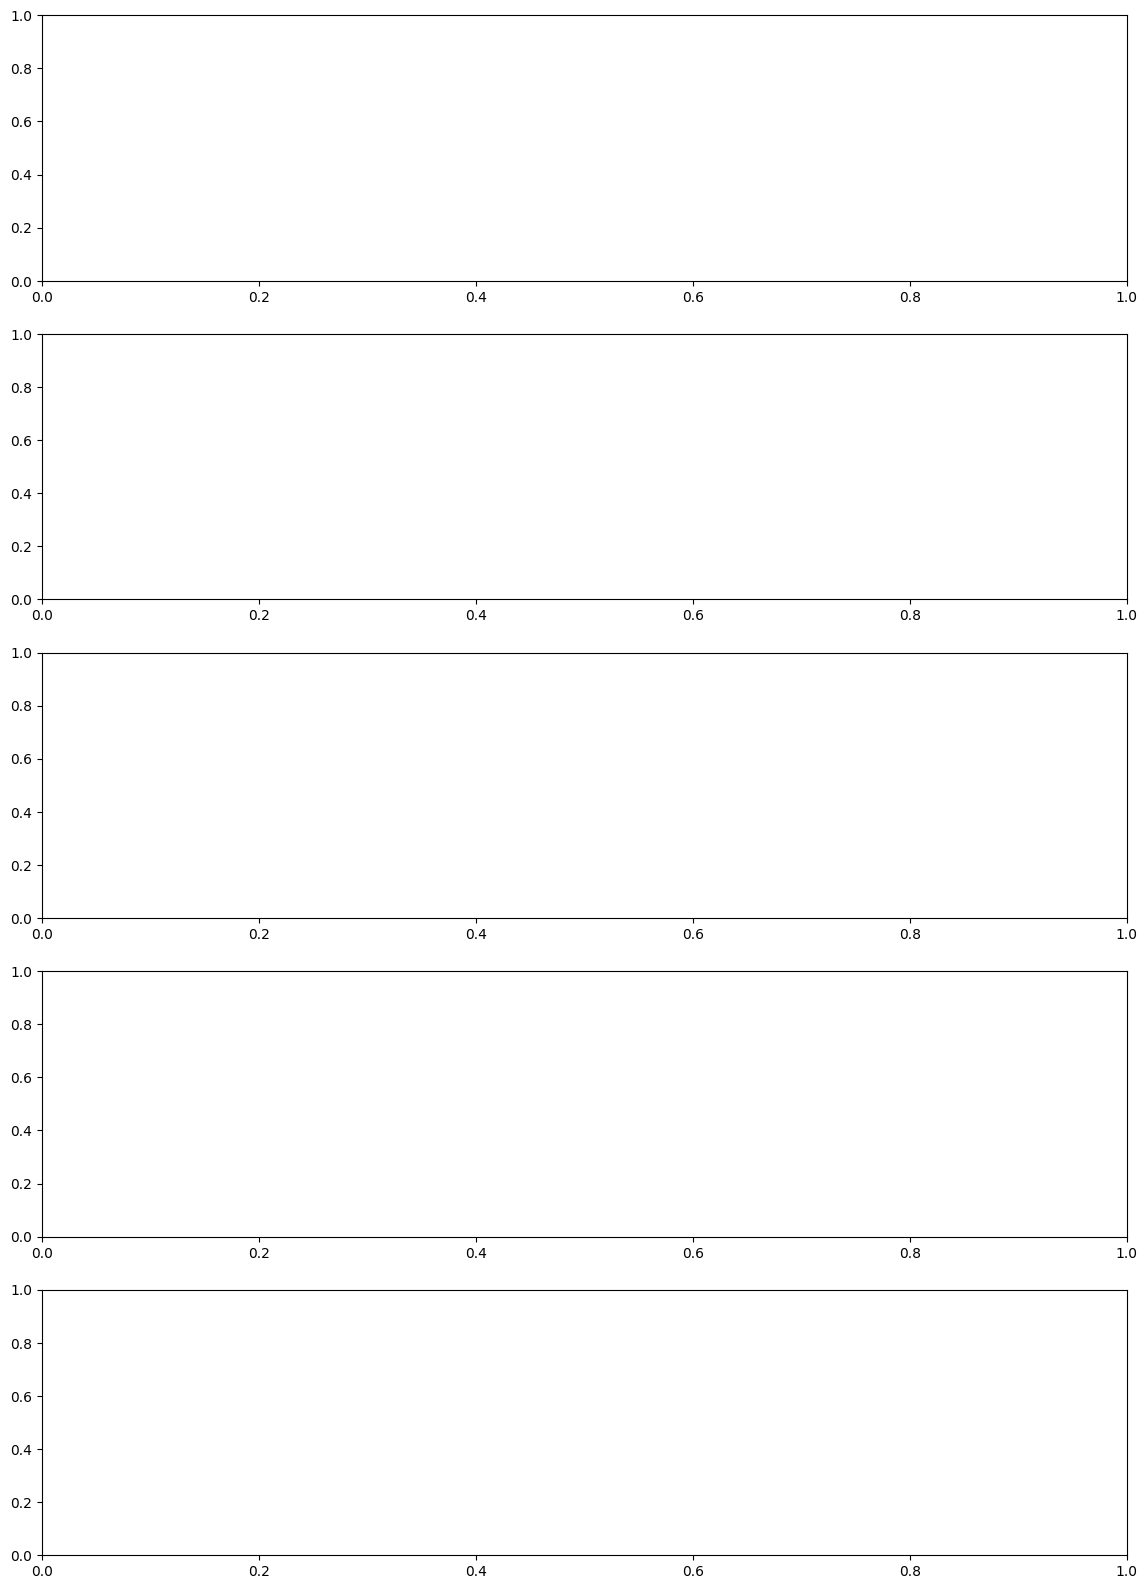

In [5]:
# Cell 5 — Visualisation
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False)

for ax, (loc_name, (lat, lon)) in zip(axes, LOCATIONS.items()):
    # Rerun best seed for plotting
    X_tr, y_tr, X_te, y_te, scaler, n_train, n_test = get_data(loc_name)
    tf.random.set_seed(42); np.random.seed(42)
    m = build_lstm_point()
    m.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss='mse')
    m.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.10,
          callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0)],
          verbose=0)
    n_cal = max(30, int(len(X_tr)*0.15))
    resid = y_tr[-n_cal:] - m.predict(X_tr[-n_cal:], verbose=0).flatten()
    lo_off, hi_off = kde_quantiles(resid)
    mu_te = m.predict(X_te, verbose=0).flatten()
    lo_m  = scaler.inverse_transform((mu_te + lo_off).reshape(-1,1)).flatten()
    hi_m  = scaler.inverse_transform((mu_te + hi_off).reshape(-1,1)).flatten()
    y_m   = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
    mu_m  = scaler.inverse_transform(mu_te.reshape(-1,1)).flatten()
    covered = (y_m >= lo_m) & (y_m <= hi_m)
    picp = np.mean(covered)*100; mpiw = np.mean(hi_m - lo_m)
    x_ax = range(len(y_m))
    ax.fill_between(x_ax, lo_m, hi_m, alpha=0.3, color='steelblue', label='95% PI (KDE)')
    ax.plot(x_ax, y_m,  'k-',  lw=1.5, label='Observed')
    ax.plot(x_ax, mu_m, 'b--', lw=1.0, alpha=0.7, label='LSTM forecast')
    ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=20, zorder=5)
    ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=20, zorder=5, label='Missed')
    ax.set_title(f'{loc_name} ({lat}N,{lon}E) | PICP={picp:.1f}% | MPIW={mpiw:.4f}m', fontsize=9)
    ax.set_ylabel('SLA (m)'); ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='upper right')

plt.suptitle('LSTM-KDE: Prediction Intervals (95% target) — Indian Ocean SLA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_LSTM_KDE.png'), dpi=120, bbox_inches='tight')
plt.show()